In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Loading the dataset
# Note: Ensure the file name matches exactly what was uploaded
df = pd.read_csv('supermarket_sales - Sheet1.csv')

# Inspecting Data Quality
print("--- Dataset Shape ---")
print(df.shape)
print("\n--- Missing Values ---")
print(df.isnull().sum())

# Convert Data Types
df['Date'] = pd.to_datetime(df['Date'])
df['Time'] = pd.to_datetime(df['Time'], format='%H:%M').dt.time

# Extract Hour for Time Analysis
# Convert Time into a temporary datetime object to  grab the hour integer (0-23)
df['Hour'] = pd.to_datetime(df['Time'], format='%H:%M:%S', errors='coerce').dt.hour
# Fallback if time format varies slightly:
if df['Hour'].isnull().any():
    df['Hour'] = pd.to_datetime(df['Time'], format='%H:%M', errors='coerce').dt.hour

print("\nData successfully prepared.")

--- Dataset Shape ---
(1000, 17)

--- Missing Values ---
Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Total                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64

Data successfully prepared.


In [8]:
# Sales and Order Count by Categorical Dimensions
dimensions = ['Branch', 'Product line', 'Customer type', 'Gender']

for dim in dimensions:
    print(f"\n- Aggregation by {dim} -")
    summary = df.groupby(dim).agg(
        Total_Sales=('Total', 'sum'),
        Order_Count=('Total', 'count')
    ).reset_index()
    print(summary)

# Hourly Traffic Breakdown
hourly_sales = df.groupby('Hour').agg(
    Order_Count=('Invoice ID', 'count'),
    Total_Revenue=('Total', 'sum')
).sort_values(by='Order_Count', ascending=False)

print("\n- Busiest Hours -")
print(hourly_sales.head(3))


- Aggregation by Branch -
  Branch  Total_Sales  Order_Count
0      A  106200.3705          340
1      B  106197.6720          332
2      C  110568.7065          328

- Aggregation by Product line -
             Product line  Total_Sales  Order_Count
0  Electronic accessories   54337.5315          170
1     Fashion accessories   54305.8950          178
2      Food and beverages   56144.8440          174
3       Health and beauty   49193.7390          152
4      Home and lifestyle   53861.9130          160
5       Sports and travel   55122.8265          166

- Aggregation by Customer type -
  Customer type  Total_Sales  Order_Count
0        Member   164223.444          501
1        Normal   158743.305          499

- Aggregation by Gender -
   Gender  Total_Sales  Order_Count
0  Female   167882.925          501
1    Male   155083.824          499

- Busiest Hours -
      Order_Count  Total_Revenue
Hour                            
19            113     39699.5130
13            103     3

C:\Users\nusre\AppData\Local\Temp\ipykernel_18924\1252041545.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=product_sales, x='Total', y='Product line', palette='Blues_r', edgecolor='black')


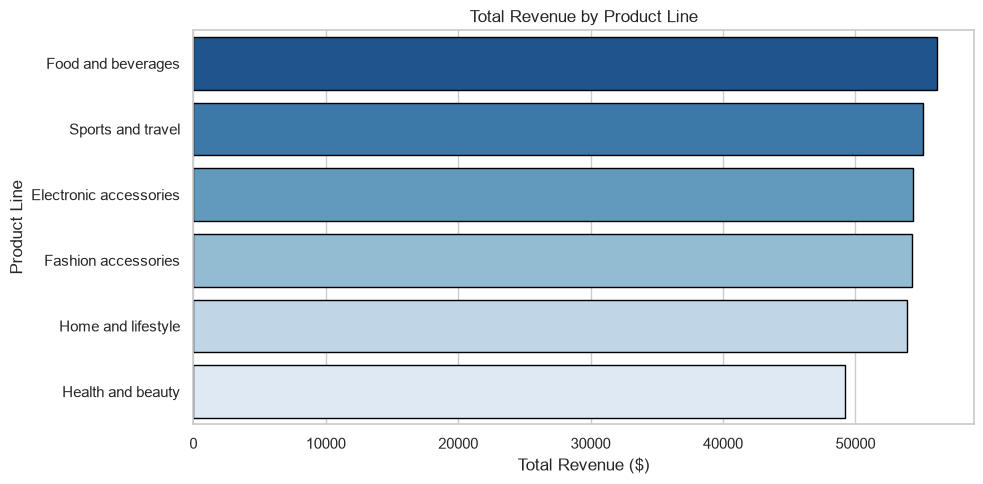

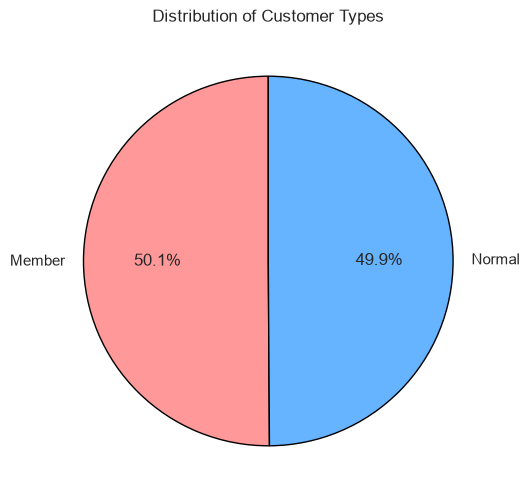

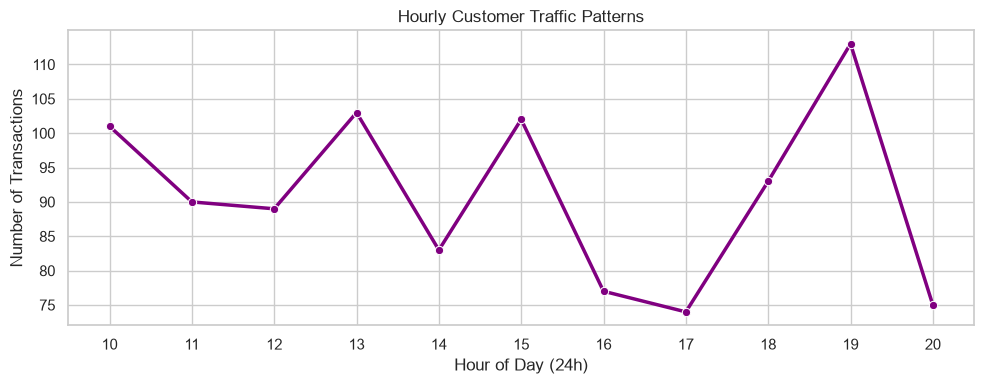

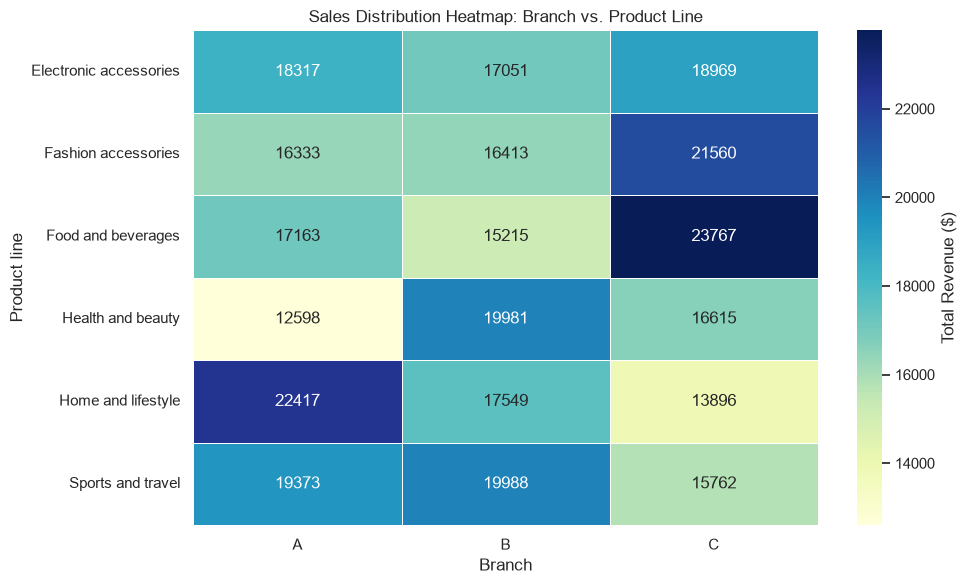

In [9]:
# Setting the design style for plots
sns.set_theme(style="whitegrid")

# Plot 1: Bar Chart of Sales by Product Line
plt.figure(figsize=(10, 5))
product_sales = df.groupby('Product line')['Total'].sum().sort_values(ascending=False).reset_index()
sns.barplot(data=product_sales, x='Total', y='Product line', palette='Blues_r', edgecolor='black')
plt.title('Total Revenue by Product Line')
plt.xlabel('Total Revenue ($)')
plt.ylabel('Product Line')
plt.tight_layout()
plt.show()

# Plot 2: Pie Chart of Customer Type
plt.figure(figsize=(6, 6))
customer_counts = df['Customer type'].value_counts()
plt.pie(customer_counts, labels=customer_counts.index, autopct='%1.1f%%', colors=['#ff9999','#66b3ff'], startangle=90, wedgeprops={'edgecolor': 'black'})
plt.title('Distribution of Customer Types')
plt.show()

# Plot 3: Line Chart of Hourly Traffic Patterns
plt.figure(figsize=(10, 4))
hourly_trends = df.groupby('Hour')['Invoice ID'].count().reset_index()
sns.lineplot(data=hourly_trends, x='Hour', y='Invoice ID', marker='o', color='purple', linewidth=2.5)
plt.title('Hourly Customer Traffic Patterns')
plt.xlabel('Hour of Day (24h)')
plt.ylabel('Number of Transactions')
plt.xticks(range(10, 21)) # The dataset captures typical operating hours
plt.tight_layout()
plt.show()

#  Heatmap of Sales by Branch and Product Line
plt.figure(figsize=(10, 6))
sales_pivot = df.pivot_table(values='Total', index='Product line', columns='Branch', aggfunc='sum')
sns.heatmap(sales_pivot, annot=True, fmt=".0f", cmap="YlGnBu", linewidths=.5, cbar_kws={'label': 'Total Revenue ($)'})
plt.title('Sales Distribution Heatmap: Branch vs. Product Line')
plt.tight_layout()
plt.show()